# CEOAI:  - Baseline
## "Project KRAKEN" Implementation

### Task Summary
We are processing sensor data from a singularity (X-99). The goal is to solve three subtasks:
1.  **Geodesic Rectification**: Predict 10 spline coefficients to un-warp time.
2.  **Topological Classification**: Identify the entity class (0-49) or "Abyssal" (-1).
3.  **Heisenberg Stability**: Predict a stability scalar (0.0 to 1.0).

### Dataset
- **Slices**: (N, 3, 128, 128) - 2D holographic data.
- **Echoes**: (N, 1024, 2) - Gravitational wave time series.
- **Glyphs**: Metadata/Telemetry (CSV).
- **Targets**: Ground truth labels.

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuration
PROJECT_DIR = Path(r"D:\projects\Supervised-Learning-Experiments\olympiads\competition_samples\raw\ceoai-2026-practice-rounds\round-1\project_kraken")
REQUIRED_DATA_FILES = [
    "train_slices.npy",
    "test_slices.npy",
    "train_echoes.npy",
    "test_echoes.npy",
    "train_targets.csv",
    "test_glyphs.csv",
]

def has_required_data(path):
    return all((path / name).exists() for name in REQUIRED_DATA_FILES)

data_candidates = [
    Path("starter_kit") / "dataset" / "dataset",  # full local starter-kit data
    Path("dataset") / "dataset",                  # common extracted starter-kit layout
    Path("data"),                                  # judge/local fixture fallback
    PROJECT_DIR / "starter_kit" / "dataset" / "dataset",
    PROJECT_DIR / "data",
]
DATA_DIR = next((path.resolve() for path in data_candidates if has_required_data(path)), None)
if DATA_DIR is None:
    searched = "\n".join(str(path) for path in data_candidates)
    raise FileNotFoundError(f"Could not find Project KRAKEN data files. Searched:\n{searched}")

SUBMISSION_FILE = "submission.csv"

print(f"Environment setup complete. Data: {DATA_DIR}")

Environment setup complete. Data: D:\projects\Supervised-Learning-Experiments\olympiads\competition_samples\raw\ceoai-2026-practice-rounds\round-1\project_kraken\starter_kit\dataset\dataset


In [21]:
print("Loading datasets...")

# Load Binary Files (Numpy)
X_train_slices = np.load(DATA_DIR / "train_slices.npy")
X_test_slices = np.load(DATA_DIR / "test_slices.npy")

X_train_echoes = np.load(DATA_DIR / "train_echoes.npy")
X_test_echoes = np.load(DATA_DIR / "test_echoes.npy")

# Load Tables
df_train_targets = pd.read_csv(DATA_DIR / "train_targets.csv")
df_test_glyphs = pd.read_csv(DATA_DIR / "test_glyphs.csv")
df_train_glyphs = pd.read_csv(DATA_DIR / "train_glyphs.csv")

def first_existing_column(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    raise KeyError(f"None of these columns exist: {candidates}. Available: {list(df.columns)}")

def parse_coeffs(value):
    return np.array([float(x) for x in str(value).split(";")], dtype=np.float32)

# Support both the tiny local fixture schema and the official starter-kit schema.
coef_cols = sorted(
    [column for column in df_train_targets.columns if column.startswith("coef_")],
    key=lambda column: int(column.split("_")[1]),
)
if len(coef_cols) == 10:
    y_train_s1 = df_train_targets[coef_cols].to_numpy(dtype=np.float32)
else:
    coeff_col = first_existing_column(df_train_targets, ["s1_coeffs", "spline_coeffs"])
    y_train_s1 = np.stack(df_train_targets[coeff_col].apply(parse_coeffs).values)

class_col = first_existing_column(df_train_targets, ["s2_class", "class_label", "topology_class"])
stability_col = first_existing_column(df_train_targets, ["s3_stability", "stability_index", "stability"])
y_train_s2 = df_train_targets[class_col].to_numpy()
y_train_s3 = df_train_targets[stability_col].to_numpy(dtype=np.float32)

print(f"Train Slices Shape: {X_train_slices.shape}")
print(f"Train Echoes Shape: {X_train_echoes.shape}")
print(f"Targets Loaded: {len(df_train_targets)}")
print(f"Target columns: coeffs={coef_cols if len(coef_cols) == 10 else coeff_col}, class={class_col}, stability={stability_col}")

Loading datasets...
Train Slices Shape: (12000, 3, 128, 128)
Train Echoes Shape: (12000, 1024, 2)
Targets Loaded: 12000
Target columns: coeffs=spline_coeffs, class=class_label, stability=stability_index


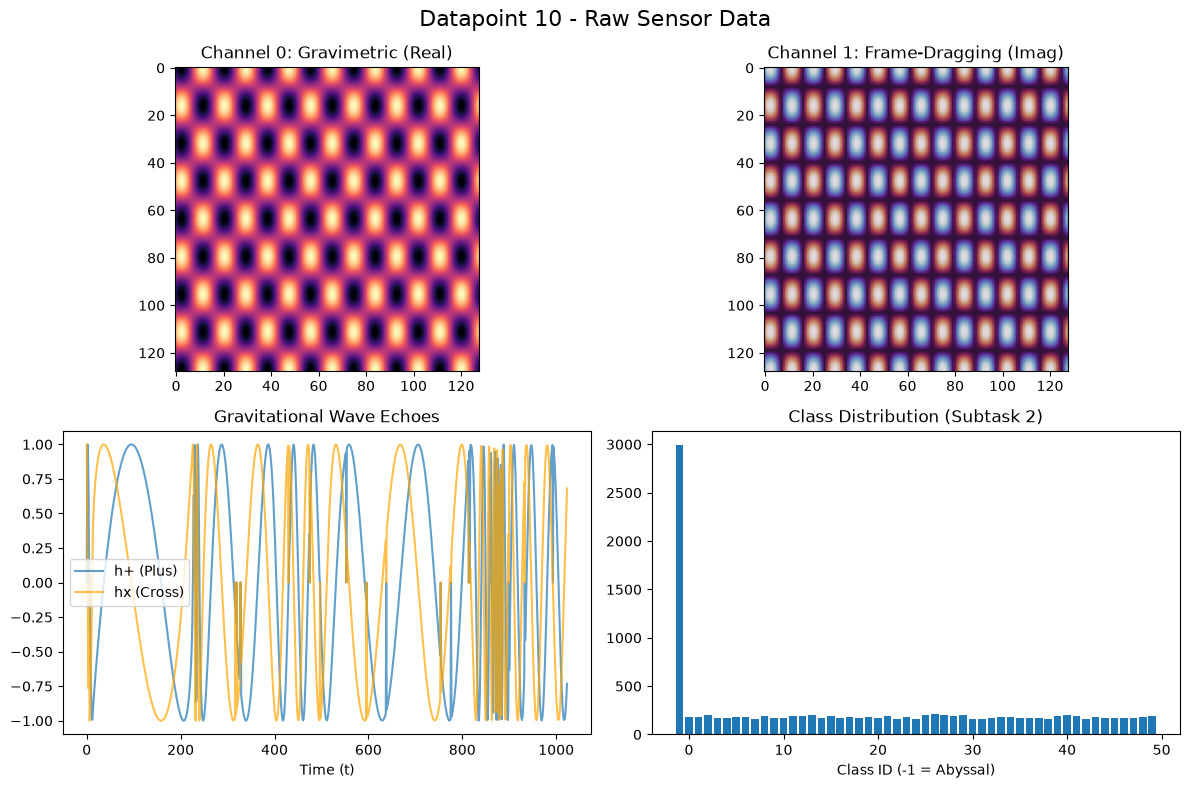

In [22]:
# Visualize a single datapoint (Index 0)
idx = 10

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"Datapoint {idx} - Raw Sensor Data", fontsize=16)

# 1. Visualizing Slices (The 2D Holograms)
# Channel 0: Gravimetric Potential (Real)
ax[0, 0].imshow(X_train_slices[idx, 0, :, :], cmap='magma')
ax[0, 0].set_title("Channel 0: Gravimetric (Real)")

# Channel 1: Frame-dragging (Imaginary)
ax[0, 1].imshow(X_train_slices[idx, 1, :, :], cmap='twilight')
ax[0, 1].set_title("Channel 1: Frame-Dragging (Imag)")

# 2. Visualizing Echoes (Gravitational Waves)
# Plotting the Plus (+) and Cross (x) polarization over time
time_steps = np.arange(1024)
ax[1, 0].plot(time_steps, X_train_echoes[idx, :, 0], label='h+ (Plus)', alpha=0.7)
ax[1, 0].plot(time_steps, X_train_echoes[idx, :, 1], label='hx (Cross)', alpha=0.7, color='orange')
ax[1, 0].set_title("Gravitational Wave Echoes")
ax[1, 0].legend()
ax[1, 0].set_xlabel("Time (t)")

# 3. Distribution of Classes (Target)
unique, counts = np.unique(y_train_s2, return_counts=True)
ax[1, 1].bar(unique, counts)
ax[1, 1].set_title("Class Distribution (Subtask 2)")
ax[1, 1].set_xlabel("Class ID (-1 = Abyssal)")

plt.tight_layout()
plt.show()

In [23]:
def print_dir(obj):
    for i in dir(obj):
        if i.startswith("_"):
            continue
        print(i)

In [24]:
# ---------------------------------------------------------------
# NAIVE BASELINE MODEL
# Strategy: Ignore input features. Predict Mean/Mode of training set.
# ---------------------------------------------------------------

print("Training Naive Models...")

# Subtask 1: Geodesic Rectification (Regression)
# Strategy: Calculate the average coefficient vector across all training examples.
# If the warping is somewhat consistent, this gives a baseline score.
mean_coeffs = np.mean(y_train_s1, axis=0)
print(mean_coeffs.shape)
print(f"Subtask 1 Baseline: Predicting constant vector {mean_coeffs[:2]}...")

# Subtask 2: Topological Classification (Classification)
# Strategy: Predict the Mode (Most Frequent Class).
# In a real scenario, "Abyssal" (-1) might be rare or common.
from scipy import stats
mode_class = int(stats.mode(y_train_s2)[0])
print(f"Subtask 2 Baseline: Predicting majority class {mode_class}")

# Subtask 3: Heisenberg Stability (Regression)
# Strategy: Predict the global mean stability.
mean_stability = float(np.mean(y_train_s3))
print(f"Subtask 3 Baseline: Predicting mean stability {mean_stability:.4f}")

Training Naive Models...
(10,)
Subtask 1 Baseline: Predicting constant vector [0.        0.1105252]...
Subtask 2 Baseline: Predicting majority class -1
Subtask 3 Baseline: Predicting mean stability 0.4641


In [25]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = X_train_slices.reshape(X_train_slices.shape[0], 3, -1)
X = np.hstack((X.argmax(axis=2), X.max(axis=2), X.mean(axis=2), X.std(axis=2)))
X_eval = X_test_slices.reshape(X_test_slices.shape[0], 3, -1)
X_eval = np.hstack((X_eval.argmax(axis=2), X_eval.max(axis=2), X_eval.mean(axis=2), X_eval.std(axis=2)))
print(X.shape)
ds = df_train_targets["spline_coeffs"].to_list()
y = []
for i in ds:
    y.append(np.array(i.split(";"), dtype=np.float32))
y = np.array(y)
print(y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

(12000, 12)
(12000, 10)


In [26]:
model1 = RandomForestRegressor()
print(X_train.shape, y_train.shape)
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
loss = mean_squared_error(y_test, y_pred)
print(loss)

(9600, 12) (9600, 10)
0.014770518707568014


In [27]:
subtask1 = model1.predict(X_eval) 

In [28]:
model3 = RandomForestRegressor()
X = X_train_slices.reshape(X_train_slices.shape[0], 3, -1)
X = np.hstack((X.argmax(axis=2), X.max(axis=2), X.mean(axis=2), X.std(axis=2)))
y = df_train_targets["stability_index"].to_numpy()
print(X.shape)
print(y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

(12000, 12)
(12000,)


In [29]:
from sklearn.metrics import root_mean_squared_error

model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)
print(y_pred.shape)
score = root_mean_squared_error(y_test, y_pred)
print(score)

(2400,)
0.11396880093018097


In [30]:
subtask3 = model3.predict(X_eval)
print(subtask3.shape)

(3000,)


In [31]:
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    token_pattern=r"[^\s]+",
    lowercase=False,
)
train_glyphs = df_train_glyphs.to_numpy()[:,1]
test_glyphs = df_test_glyphs.to_numpy()[:,1]
# print(glyphs.shape)
train_embs = vectorizer.fit_transform(train_glyphs).toarray();
test_embs = vectorizer.transform(test_glyphs).toarray();
print(type(train_embs))

<class 'numpy.ndarray'>


In [32]:
# print_dir(sklearn.ensemble)

In [33]:
model2 = XGBClassifier()
X = X_train_slices.reshape(X_train_slices.shape[0], 3, -1)
print(X.argmax(axis=2).shape)
print(train_embs[:, :3].shape)
X = np.hstack((
    X.argmax(axis=2), 
    X.max(axis=2), 
    X.mean(axis=2), 
    X.std(axis=2), 
    train_embs
))
print(X.shape)
y = df_train_targets["class_label"].to_numpy()+1
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

(12000, 3)
(12000, 3)
(12000, 18)


In [34]:
from sklearn.metrics import f1_score


model2.fit(X_train, y_train);
y_pred = model2.predict(X_test)
print(np.vstack((y_test, y_pred)))
score = f1_score(y_test, y_pred, average="macro")
print(score)

[[50  1  0 ...  1 19 50]
 [50  1  0 ...  8 19 50]]
0.793665268788391


In [35]:
X_eval = np.hstack((X_eval, test_embs))

In [36]:
subtask2 = model2.predict(X_eval)-1
print(subtask2.max(), subtask2.min())

49 -1


In [37]:
# ---------------------------------------------------------------
# GENERATE SUBMISSION FILE
# ---------------------------------------------------------------

submission_rows = []

# Get list of test IDs from the glyphs file (or just generate based on N_TEST)
test_ids = df_test_glyphs['datapointID'].values

print(f"Generating predictions for {len(test_ids)} test items...")

for idx, tid in enumerate(test_ids):
    # --- Subtask 1: Coefficients ---
    # Format: "f1;f2;f3..."
    # We use our calculated mean_coeffs
    s1_pred_str = ";".join([f"{subtask1[idx][i]:.6f}" for i in range(len(subtask1[idx]))])
    submission_rows.append([1, tid, s1_pred_str])

    # --- Subtask 2: Class ---
    # We use our calculated mode_class
    submission_rows.append([2, tid, subtask2[idx]])

    # --- Subtask 3: Stability ---
    # We use our calculated mean_stability
    submission_rows.append([3, tid, f"{subtask3[idx]:.6f}"])

# Create DataFrame
df_submission = pd.DataFrame(submission_rows, columns=['subtaskID', 'datapointID', 'answer'])

# Save
df_submission.to_csv(SUBMISSION_FILE, index=False)

print("------------------------------------------------")
print(f"Submission saved to {SUBMISSION_FILE}")
print("Head of submission:")
print(df_submission.head())

Generating predictions for 3000 test items...
------------------------------------------------
Submission saved to submission.csv
Head of submission:
   subtaskID datapointID                                             answer
0          1  test_00000  0.000000;0.126382;0.237307;0.339170;0.450400;0...
1          2  test_00000                                                  1
2          3  test_00000                                           0.466198
3          1  test_00001  0.000000;0.110244;0.212607;0.330485;0.446712;0...
4          2  test_00001                                                  4
